# COMP316 – Naive Bayes Sentiment Classifier
**Steam Reviews Dataset**



## 1. Install & Import

In [ ]:
##########################################################
#                      1. INSTALL & IMPORTS
#
# Core libraries:
#   pandas        → data loading and manipulation
#   numpy         → numerical operations
#   re            → regular expressions for text cleaning
#   time          → training duration tracking
#   matplotlib    → confusion matrix and feature plots
#   seaborn       → confusion matrix heatmap styling
#
# NLTK:
#   stopwords     → common English words to remove
#                   (e.g. 'the', 'is', 'and')
#   PorterStemmer → reduces words to their root form
#                   (e.g. 'playing' → 'play')
#
# Scikit-learn:
#   TfidfVectorizer    → converts cleaned text into
#                        TF-IDF feature vectors
#   MultinomialNB      → Naive Bayes classifier
#   accuracy_score etc → evaluation metrics
##########################################################
!pip install nltk scikit-learn pandas matplotlib seaborn -q

from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/COMP316_Project_CleanedData'
print(os.listdir(path))

import pandas as pd
import numpy as np
import re
import time
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

nltk.download('stopwords', quiet=True)
print('All imports successful.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['steam_reviews_test_WITH_SENTIMENT_FINAL.csv', 'steam_reviews_test_NO_SENTIMENT_FINAL.csv', 'steam_reviews_train_FINAL.csv']
All imports successful.


## 2. Load Data

In [ ]:
##########################################################
#                     2. LOAD DATA
#
# Three files are loaded:
#
#   steam_reviews_train_FINAL.csv
#     42,000 reviews with sentiment labels (0 or 1).
#     Used to fit the TF-IDF vectoriser and train
#     the Naive Bayes classifier.
#     Balanced: 21,000 positive, 21,000 negative.
#
#   steam_reviews_test_NO_SENTIMENT_FINAL.csv
#     18,000 reviews WITHOUT sentiment labels.
#     Used as input for generating predictions.
#     The model only sees the review text.
#
#   steam_reviews_test_WITH_SENTIMENT_FINAL.csv
#     18,000 reviews WITH sentiment labels.
#     Used to evaluate prediction accuracy AFTER
#     predictions have been generated.
#     Never exposed to the model during training
#     or inference. True labels are aligned by
#     review_id to ensure correct row matching.
#
# NOTE ON CONSISTENCY:
#   No subsampling is applied. Naive Bayes trains
#   and evaluates on the full dataset, identical
#   to the LSTM and BERT notebooks, ensuring all
#   three models are compared on equal footing.
##########################################################
train_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_train_FINAL.csv', encoding='utf-8-sig')
test_no_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_NO_SENTIMENT_FINAL.csv', encoding='utf-8-sig')
test_with_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_WITH_SENTIMENT_FINAL.csv', encoding='utf-8-sig')

print('Train shape:', train_df.shape)
print('Test (no sentiment) shape:', test_no_sent_df.shape)
print('Test (with sentiment) shape:', test_with_sent_df.shape)
print()
print('Train columns:', train_df.columns.tolist())
print()
print('Sentiment distribution in train:')
print(train_df['sentiment'].value_counts())
print()
train_df.head(3)

Train shape: (42000, 5)
Test (no sentiment) shape: (18000, 4)
Test (with sentiment) shape: (18000, 5)

Train columns: ['review_id', 'app_id', 'review_text', 'sentiment', 'helpful_score']

Sentiment distribution in train:
sentiment
1    21000
0    21000
Name: count, dtype: int64



,review_id,app_id,review_text,sentiment,helpful_score
0,1,4000,I remember watching so much content based arou...,1,0.50000
1,2,489830,"man i love this game, i grew up with it (i did...",0,0.50000
2,3,8870,You know the storyline is marvelous when you w...,1,0.52381


## 3. Text Preprocessing
Clean review text: lowercase, remove noise, remove stopwords, apply stemming.

In [ ]:
##########################################################
#                  3. TEXT PREPROCESSING
#
# Naive Bayes with TF-IDF requires explicit text
# preprocessing — unlike BERT, it has no pre-trained
# representations to compensate for noise in raw text.
#
# STEPS APPLIED:
#
#   1. Lowercase
#      Ensures 'Good' and 'good' are treated as the
#      same token. Reduces vocabulary size.
#
#   2. Remove non-alphabetic characters
#      Strips punctuation, numbers, and symbols.
#      These rarely carry sentiment signal in
#      a bag-of-words representation.
#
#   3. Remove stopwords
#      Common English words ('the', 'is', 'and')
#      that appear in both positive and negative
#      reviews with similar frequency. Removing them
#      reduces noise in the TF-IDF matrix.
#      NOTE: Unlike LSTM, all stopwords are removed
#      including negations, as bigrams (n-gram range
#      (1,2)) partially capture negation context.
#
#   4. Porter Stemming
#      Reduces words to their morphological root:
#        'crashes' → 'crash'
#        'playing' → 'play'
#        'boring'  → 'bore'
#      Groups related forms under one token, reducing
#      vocabulary size and improving coverage.
#      Note: LSTM does not stem as it learns word
#      relationships from context. BERT does not stem
#      as WordPiece handles morphology implicitly.
##########################################################
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Lowercase, remove non-alpha chars, remove stopwords, stem."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [stemmer.stem(t) for t in tokens]            # stem
    return ' '.join(tokens)

print('Preprocessing training data...')
start = time.time()
train_df['clean_text'] = train_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

print('Preprocessing test data...')
start = time.time()
test_no_sent_df['clean_text'] = test_no_sent_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

# Preview
print('\nSample before/after preprocessing:')
print('BEFORE:', train_df['review_text'].iloc[0][:200])
print('AFTER: ', train_df['clean_text'].iloc[0][:200])

Preprocessing training data...
Done in 41.6s
Preprocessing test data...
Done in 11.3s

Sample before/after preprocessing:
BEFORE: I remember watching so much content based around this game throughout my childhood and wishing how I could get my hands on it as a kid...And buying it now in 2026?

I don't regret buying this game, 
AFTER:  rememb watch much content base around game throughout childhood wish could get hand kidand buy dont regret buy game funni wholesom moment play friend addon get marketplac also make much better overal 


## 4. TF-IDF Feature Extraction
Convert cleaned text into numerical features using TF-IDF.

In [ ]:
##########################################################
#                  4. TF-IDF VECTORISATION
#
# TF-IDF (Term Frequency-Inverse Document Frequency)
# converts cleaned review text into a numerical
# feature matrix that Naive Bayes can operate on.
#
# PARAMETERS:
#
#   max_features=50,000
#     Limits the vocabulary to the 50,000 most
#     frequent terms across the corpus. This bounds
#     memory usage while retaining the most
#     informative terms.
#
#   ngram_range=(1, 2)
#     Includes both unigrams (single words) and
#     bigrams (two-word phrases). Bigrams capture
#     simple context — e.g. 'not good' is a more
#     informative feature than 'not' or 'good' alone.
#
#   min_df=2
#     Ignores terms appearing in fewer than 2
#     documents. Removes highly rare/misspelled
#     words that add noise without signal.
#
#   sublinear_tf=True
#     Applies log(1 + tf) scaling to term frequencies.
#     Prevents very high-frequency terms from
#     dominating the feature space — a single word
#     appearing 100 times should not carry 100x
#     the weight of one appearing once.
#
# CRITICAL: The vectoriser is fit ONLY on training data.
# The test set is transformed using the training
# vocabulary — it never influences the feature space.
# This prevents data leakage.
##########################################################
tfidf = TfidfVectorizer(
    max_features=50000,   # top 50k terms
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore terms in fewer than 2 docs
    sublinear_tf=True     # apply log normalization to TF
)

print('Fitting TF-IDF on training data...')
start = time.time()
X_train = tfidf.fit_transform(train_df['clean_text'])
print(f'Done in {time.time()-start:.1f}s')
print(f'Feature matrix shape: {X_train.shape}')  # (42000, vocab_size)

print('Transforming test data...')
X_test = tfidf.transform(test_no_sent_df['clean_text'])
print(f'Test feature matrix shape: {X_test.shape}')

y_train = train_df['sentiment']
y_test_true = test_with_sent_df.set_index('review_id').loc[test_no_sent_df['review_id']]['sentiment'].values

Fitting TF-IDF on training data...
Done in 8.9s
Feature matrix shape: (42000, 50000)
Transforming test data...
Test feature matrix shape: (18000, 50000)


## 5. Train Naive Bayes Model

In [ ]:
##########################################################
#               5. TRAIN NAIVE BAYES CLASSIFIER
#
# MultinomialNB is trained on the TF-IDF feature matrix.
#
# HOW IT WORKS:
#   Naive Bayes estimates the probability of each class
#   given the observed word frequencies, using Bayes'
#   Theorem:
#
#     P(class | words) ∝ P(class) × ∏ P(word | class)
#
#   At prediction time, the class with the highest
#   posterior probability is assigned.
#
# PARAMETER:
#
#   alpha=1.0 (Laplace Smoothing)
#     Adds a count of 1 to every term in every class,
#     even if that term was never seen during training.
#     This prevents zero-probability terms from making
#     the entire product zero for unseen words in the
#     test set.
#
# Training Naive Bayes is extremely fast — it requires
# only a single pass over the training data to compute
# class priors and conditional probabilities. No
# iterative optimisation is needed, unlike LSTM and BERT.
##########################################################
rint('Training Multinomial Naive Bayes...')
start = time.time()

nb_model = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
nb_model.fit(X_train, y_train)

training_time = time.time() - start
print(f'Training complete in {training_time:.2f}s')

Training Multinomial Naive Bayes...
Training complete in 0.03s


## 6. Predict on Test Set

In [ ]:
##########################################################
#               6. PREDICT ON TEST SET
#
# Predictions are generated on the test set that
# contains NO sentiment labels (test_no_sent_df).
#
# The model only sees the TF-IDF feature vector
# derived from review_text — it has no access to
# true labels during inference.
#
# nb_model.predict():
#   Returns the class (0 or 1) with the highest
#   posterior probability for each review.
#
# TRUE LABEL ALIGNMENT:
#   After generating predictions, true labels are
#   retrieved from test_with_sent_df using review_id
#   to ensure correct row-by-row alignment.
#   This is consistent with the LSTM and BERT
#   notebooks, ensuring evaluation is comparable.
##########################################################
print('Generating predictions...')
start = time.time()
y_pred = nb_model.predict(X_test)
inference_time = time.time() - start
print(f'Inference complete in {inference_time:.2f}s')

# Save predictions alongside review_id for reference
results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment'] = y_test_true
results_df.head(10)

Generating predictions...
Inference complete in 0.01s


,review_id,predicted_sentiment,true_sentiment
0,1,0,0
1,2,1,1
2,3,1,1
3,4,0,0
4,5,0,0
5,6,1,1
6,7,0,1
7,8,0,0
8,9,0,1
9,10,1,1


## 7. Evaluate the Model
Metrics: Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [ ]:
##########################################################
#                 7. EVALUATE THE MODEL
#
# METRICS USED (consistent across all three models):
#
#   Accuracy:
#     Proportion of correctly classified reviews.
#     Primary metric for balanced datasets.
#
#   Precision:
#     Of all reviews predicted positive, how many
#     actually were? Measures false positive rate.
#
#   Recall:
#     Of all actually positive reviews, how many
#     did the model correctly identify? Measures
#     false negative rate.
#
#   F1-Score:
#     Harmonic mean of precision and recall.
#     Most informative single metric for comparing
#     classification models.
#
# These four metrics are recorded for all three models
# (Naive Bayes, LSTM, BERT) enabling direct side-by-side
# comparison in the project report.
##########################################################
acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('='*45)
print('     NAIVE BAYES EVALUATION RESULTS')
print('='*45)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision: {precision:.4f}')
print(f'  Recall   : {recall:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  Train Time: {training_time:.2f}s')
print(f'  Inference: {inference_time:.2f}s ({len(y_pred)} reviews)')
print('='*45)
print()
print('Full Classification Report:')
print(classification_report(y_test_true, y_pred, target_names=['Negative (0)', 'Positive (1)']))

     NAIVE BAYES EVALUATION RESULTS
  Accuracy : 0.8411  (84.11%)
  Precision: 0.8668
  Recall   : 0.8060
  F1-Score : 0.8353
  Train Time: 0.03s
  Inference: 0.01s (18000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.88      0.85      9000
Positive (1)       0.87      0.81      0.84      9000

    accuracy                           0.84     18000
   macro avg       0.84      0.84      0.84     18000
weighted avg       0.84      0.84      0.84     18000



## 8. Confusion Matrix (Visualised)

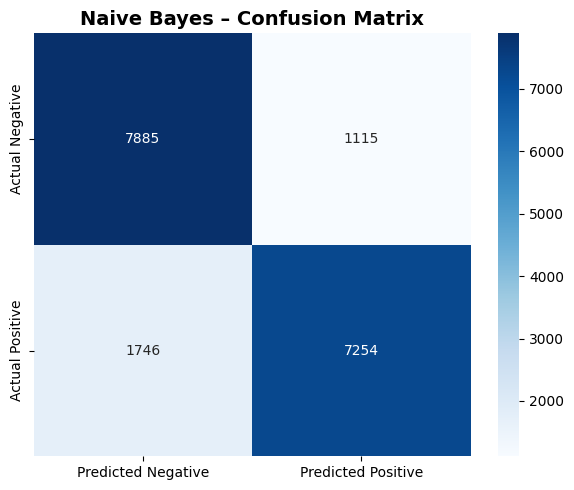

Saved as nb_confusion_matrix.png


In [ ]:
##########################################################
#                 8. CONFUSION MATRIX
#
# A confusion matrix shows the breakdown of correct
# and incorrect predictions across both classes:
#
#   True Negative  (TN): Correctly predicted negative
#   False Positive (FP): Incorrectly predicted positive
#   False Negative (FN): Incorrectly predicted negative
#   True Positive  (TP): Correctly predicted positive
#
# Saved as nb_confusion_matrix.png for the report.
# This plot is produced identically across all three
# model notebooks for visual consistency.
##########################################################
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)
plt.title('Naive Bayes – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()
print('Saved as nb_confusion_matrix.png')

## 9. Top Predictive Words
Shows which words the model considers most indicative of each sentiment class.

In [ ]:
##########################################################
#              9. TOP PREDICTIVE FEATURES
#
# One of Naive Bayes' key advantages over LSTM and BERT
# is interpretability — we can directly inspect which
# words the model finds most discriminative for each
# sentiment class.
#
# feature_log_prob_ contains the log probability of
# each feature (word/bigram) given each class:
#
#   log_probs[0] → log P(word | Negative)
#   log_probs[1] → log P(word | Positive)
#
# The words with the highest log probability for each
# class are the most strongly associated with that
# sentiment. These results are included in the report
# to validate that the model has learned meaningful
# sentiment associations rather than spurious patterns.
##########################################################
eature_names = tfidf.get_feature_names_out()
log_probs = nb_model.feature_log_prob_   # shape: (2, n_features)

# Top 15 words per class
top_n = 15
top_neg_idx = np.argsort(log_probs[0])[-top_n:][::-1]
top_pos_idx = np.argsort(log_probs[1])[-top_n:][::-1]

print('Top 15 words → NEGATIVE reviews:')
print([feature_names[i] for i in top_neg_idx])
print()
print('Top 15 words → POSITIVE reviews:')
print([feature_names[i] for i in top_pos_idx])

Top 15 words → NEGATIVE reviews:
['game', 'play', 'like', 'get', 'bore', 'dont', 'time', 'crash', 'cant', 'good', 'even', 'bad', 'make', 'realli', 'fun']

Top 15 words → POSITIVE reviews:
['game', 'good', 'great', 'fun', 'play', 'best', 'great game', 'love', 'one', 'stori', 'like', 'time', 'cool', 'ever', 'realli']


## 10. Save Results to CSV

In [ ]:
##########################################################
#                   10. SAVE RESULTS
#
# Two output files are produced:
#
#   nb_predictions.csv
#     Full prediction output: review_id,
#     predicted_sentiment, and true_sentiment
#     for every review in the test set.
#
#   nb_metrics.csv
#     Summary metrics for this model. Formatted
#     identically to the output of the LSTM and
#     BERT notebooks so all three can be combined
#     into a single comparison table in the report.
##########################################################
results_df.to_csv('nb_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved to nb_predictions.csv')

# Summary metrics saved for report
metrics_df = pd.DataFrame([{
    'Model': 'Naive Bayes',
    'Accuracy': round(acc, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1_Score': round(f1, 4),
    'Train_Time_s': round(training_time, 2),
    'Inference_Time_s': round(inference_time, 2)
}])
metrics_df.to_csv('nb_metrics.csv', index=False)
print('Metrics saved to nb_metrics.csv')
metrics_df

Predictions saved to nb_predictions.csv
Metrics saved to nb_metrics.csv


,Model,Accuracy,Precision,Recall,F1_Score,Train_Time_s,Inference_Time_s
0,Naive Bayes,0.8411,0.8668,0.806,0.8353,0.03,0.01
